In [2]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import os

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org


In [97]:
img_scale_bar = dip.Image(plt.imread("scale-img.tif"))
images = [img_scale_bar]

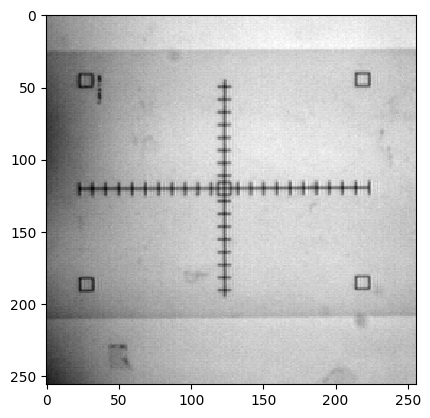

In [98]:
img_scale_bar.Show()

In [142]:
def remove_background(img, se_size=100):
	smoothened_image = dip.Gauss(img, sigmas=[10])
	estimation_of_background = dip.Closing(smoothened_image, se=se_size)
	img_after_processing = img - estimation_of_background
	return img_after_processing

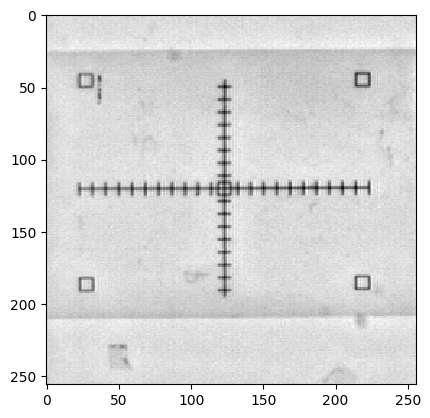

In [ ]:
improved_images = []
for image in images:
	new_img = remove_background(image, 100)
	new_img = remove_background(new_img, 250)
	new_img = remove_background(new_img, 500)
	improved_images.append(new_img)
	new_img.Show()


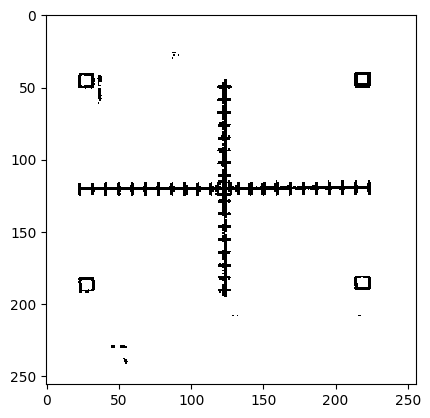

In [145]:
new_var = dip.OtsuThreshold(improved_images[0])
new_var.Show()

In [ ]:
def smooth_1d(data, sigma=20):

    window_size = int(sigma * 4) #  window size for Gaussian
    if window_size % 2 == 0: window_size += 1
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')

def find_1d_segments_centers(mask, min_length=1):

    # Find indices where mask is True
    indices = np.where(mask)[0]
    if len(indices) == 0:
        return [], 0
    
    # Find gaps in indices (where diff > 1)
    gaps = np.where(np.diff(indices) > 1)[0]
    
    centers = []
    start_idx = 0
    
    for gap_idx in gaps:
        segment = indices[start_idx : gap_idx + 1]
        if len(segment) >= min_length:
            centers.append(int(np.mean(segment)))
        start_idx = gap_idx + 1
    
    # Handle the last segment
    segment = indices[start_idx:]
    if len(segment) >= min_length:
        centers.append(int(np.mean(segment)))
        
    return centers, len(centers)

def measure_pixel_size(filepath, division_um=10.0, plot=True, imgname='image'):

    #  Load 
    img = dip.ImageReadTIFF(filepath)
    arr = np.array(img)
    h, w = arr.shape
    print(f'[{imgname}] Size: {w}x{h}px')

    #  Preprocessing 
    new_img = remove_background(img, 100)
    new_img = remove_background(new_img, 250)
    corrected = remove_background(new_img, 500)


    thresh_img = dip.Invert(dip.OtsuThreshold(corrected))
    
    # Morphological cleaning
    closed = dip.Closing(thresh_img, dip.SE(1, 'rectangular'))
    cleaned_img = dip.Opening(closed, dip.SE(1, 'rectangular'))
    clean_arr = np.array(cleaned_img).astype(bool)

    # Count Horizontal Line Starts 
    padded = np.pad(clean_arr.astype(int), ((1, 0), (0, 0)), mode='constant')
    diff = np.diff(padded, axis=0)
    starts = (diff == 1) 
    
    starts_per_col = starts.sum(axis=0)
    
    # Ignore the left 30% of the image
    search_start = int(w * 0.3)
    starts_search = starts_per_col.copy()
    starts_search[:search_start] = 0
    
    starts_smooth = smooth_1d(starts_search.astype(float), sigma=40)
    
    peak_x = np.argmax(starts_smooth)
    peak_val = starts_smooth[peak_x]
    
    print(f'  Max line starts (right side): {peak_val:.1f} at x={peak_x}')

    # Define ROI 
    threshold_level = 0.3 * peak_val
    valid_cols = np.where(starts_smooth > threshold_level)[0]
    
    if len(valid_cols) > 0:
        x_start = max(search_start, valid_cols[0] - 20) 
        x_end = min(w, valid_cols[-1] + 20)
    else:
        x_start = max(search_start, peak_x - 200)
        x_end = min(w, peak_x + 200)
        
    if x_end - x_start < 50:
        x_start = max(search_start, peak_x - 150)
        x_end = min(w, peak_x + 150)

    ruler_roi = clean_arr[:, x_start:x_end]
    
    if ruler_roi.sum() == 0:
        raise RuntimeError(f'[{imgname}] ROI is empty.')

    # Tick Locations to better understand 
    y_proj = ruler_roi.sum(axis=1)
    y_mask = y_proj > 10 
    
    tick_centers, ng = find_1d_segments_centers(y_mask, min_length=2)
    
    if ng < 3:
         y_mask = y_proj > 2
         tick_centers, ng = find_1d_segments_centers(y_mask, min_length=2)
         if ng < 3:
             raise RuntimeError(f'[{imgname}] Could not detect enough ticks (found {ng}).')

    tick_centers = np.sort(np.array(tick_centers))
    
    #  Calculate Spacing 
    spacings = np.diff(tick_centers)
    if len(spacings) == 0:
         raise RuntimeError("No spacings calculated.")
         
    median_sp = np.median(spacings)
    valid_sp = spacings[np.abs(spacings - median_sp) < 0.4 * median_sp]
    mean_sp = np.mean(valid_sp)
    
    pixel_size = division_um / mean_sp
    
    print(f'  ROI: cols {x_start}-{x_end}')
    print(f'  Ticks found: {len(tick_centers)}')
    print(f'  Mean spacing: {mean_sp:.2f} px = {division_um} µm')
    print(f'  Pixel size: {pixel_size:.4f} µm/px')

    # Plot 
    if plot:
        corr_arr = np.array(corrected)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f'{imgname}: pixel size = {pixel_size:.4f} µm/px', fontsize=14, fontweight='bold')

        axes[0].imshow(arr, cmap='gray')
        axes[0].set_title('(a) Original')
        axes[0].axis('off')

        axes[1].imshow(clean_arr, cmap='gray')
        for c in tick_centers:
            axes[1].axhline(c, color='red', alpha=0.5, lw=1)
        axes[1].set_title('(b) Cleaned Binary')
        axes[1].axis('off')

        if len(tick_centers) > 1:
            z_y0 = max(0, tick_centers[0] - 30)
            z_y1 = min(h, tick_centers[min(10, len(tick_centers)-1)] + 30)
            zoom = arr[z_y0:z_y1, x_start:x_end]
            axes[2].imshow(zoom, cmap='gray', aspect='auto')
            for c in tick_centers:
                if z_y0 <= c <= z_y1:
                    axes[2].axhline(c - z_y0, color='red', lw=1.5)
            axes[2].set_title(f'(c) Ruler Zoom\nspacing={mean_sp:.1f}px')

        plt.tight_layout()
        plt.show()

    return pixel_size, mean_sp

[image] Size: 256x256px
  Max line starts (right side): 8.6 at x=125
  ROI: cols 92-243
  Ticks found: 5
  Mean spacing: nan px = 10.0 µm
  Pixel size: nan µm/px


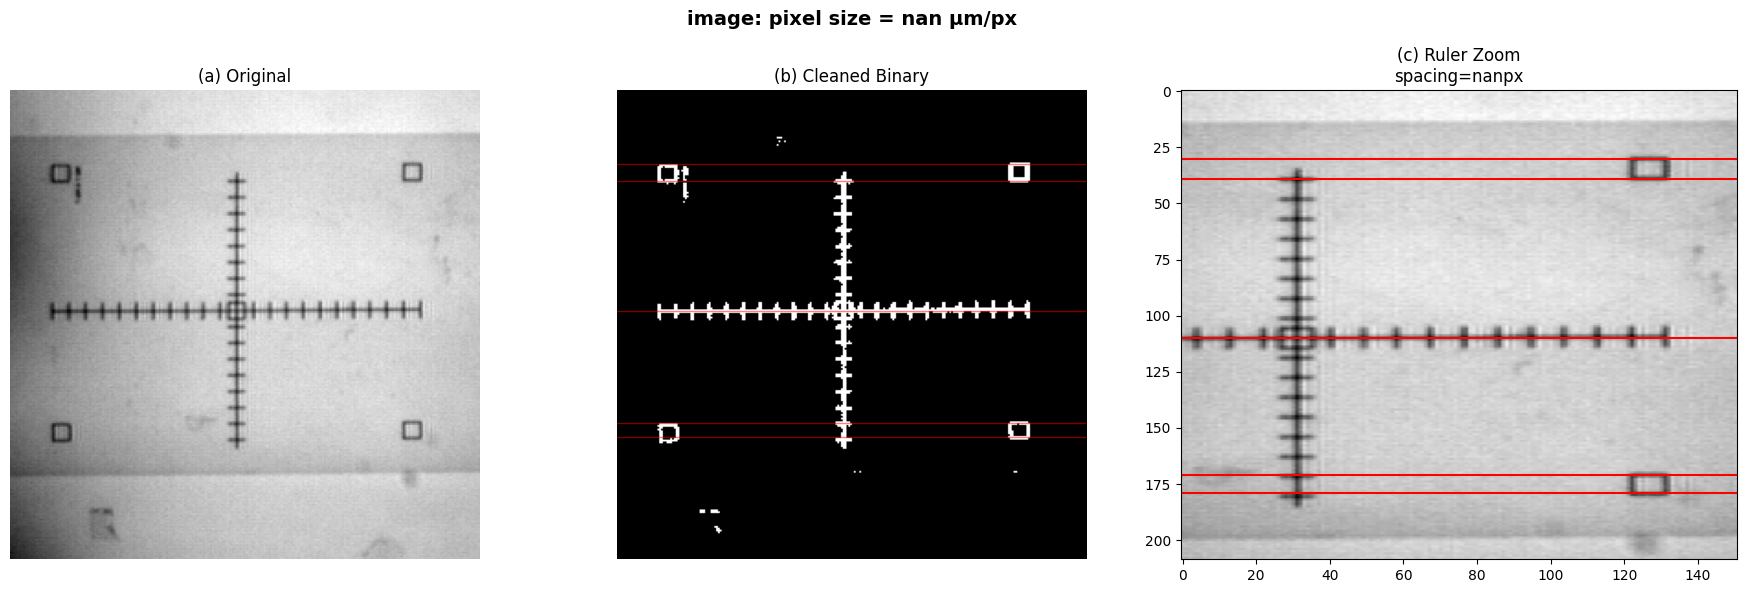

(np.float64(nan), np.float64(nan))

In [185]:
measure_pixel_size("scale-img.tif")